In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

# Loading the dataset

In [2]:
#creating dataset connection
conn=sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_sql_query('SELECT * FROM vendor_sales_summary',conn)
df.head()

,VENDORNUMBER,VENDORNAME,BRAND,DESCRIPTION,PURCHASEPRICE,ActualPrice,VOLUME,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis
- Previously, we examined the various tables in the database to identify key varibales, understand their relationship, and determine which ones should be included in the final analysis.
- In this phase of EDA, we will analyze the resultant table to gain insight into the distribution of each col. This will help us understand data patterns,identify anomalies, and ensure data quality before proceeding with further analysis.

In [3]:
#summary statistics
#T:Transform

df.describe().T


,count,mean,std,min,25%,50%,75%,max
VENDORNUMBER,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
BRAND,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PURCHASEPRICE,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
VOLUME,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


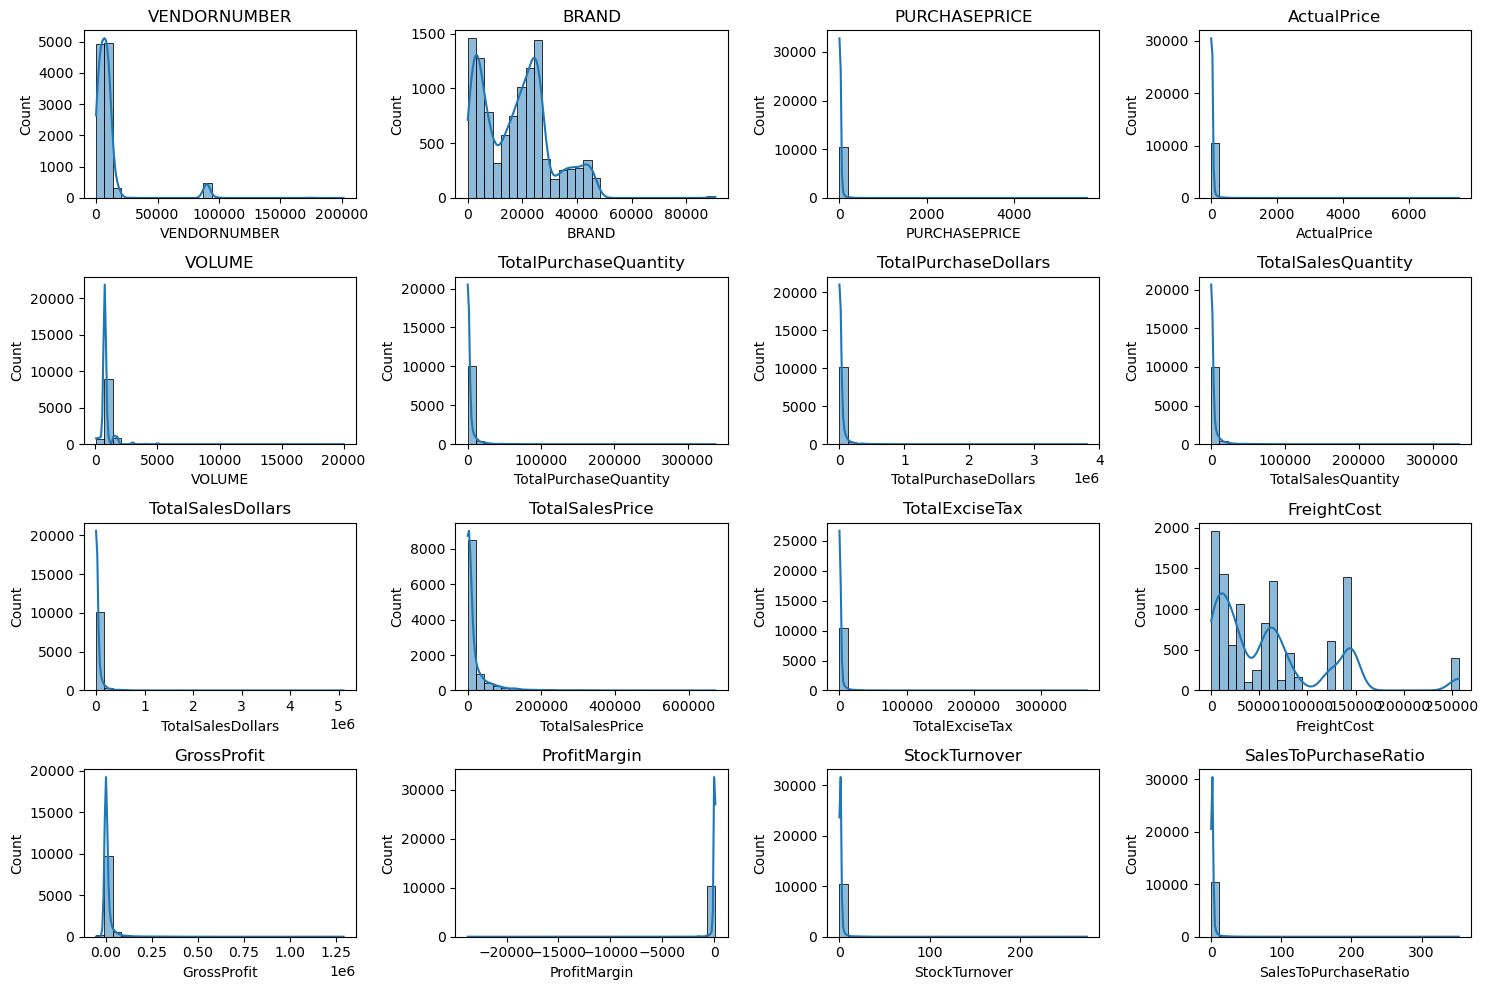

In [4]:
#Distibution plots for numerical cols:
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #adjust the grid layout as needed
    sns.histplot(df[col],kde=True, bins=30)
    plt.title(col)
plt.tight_layout() 
plt.show()

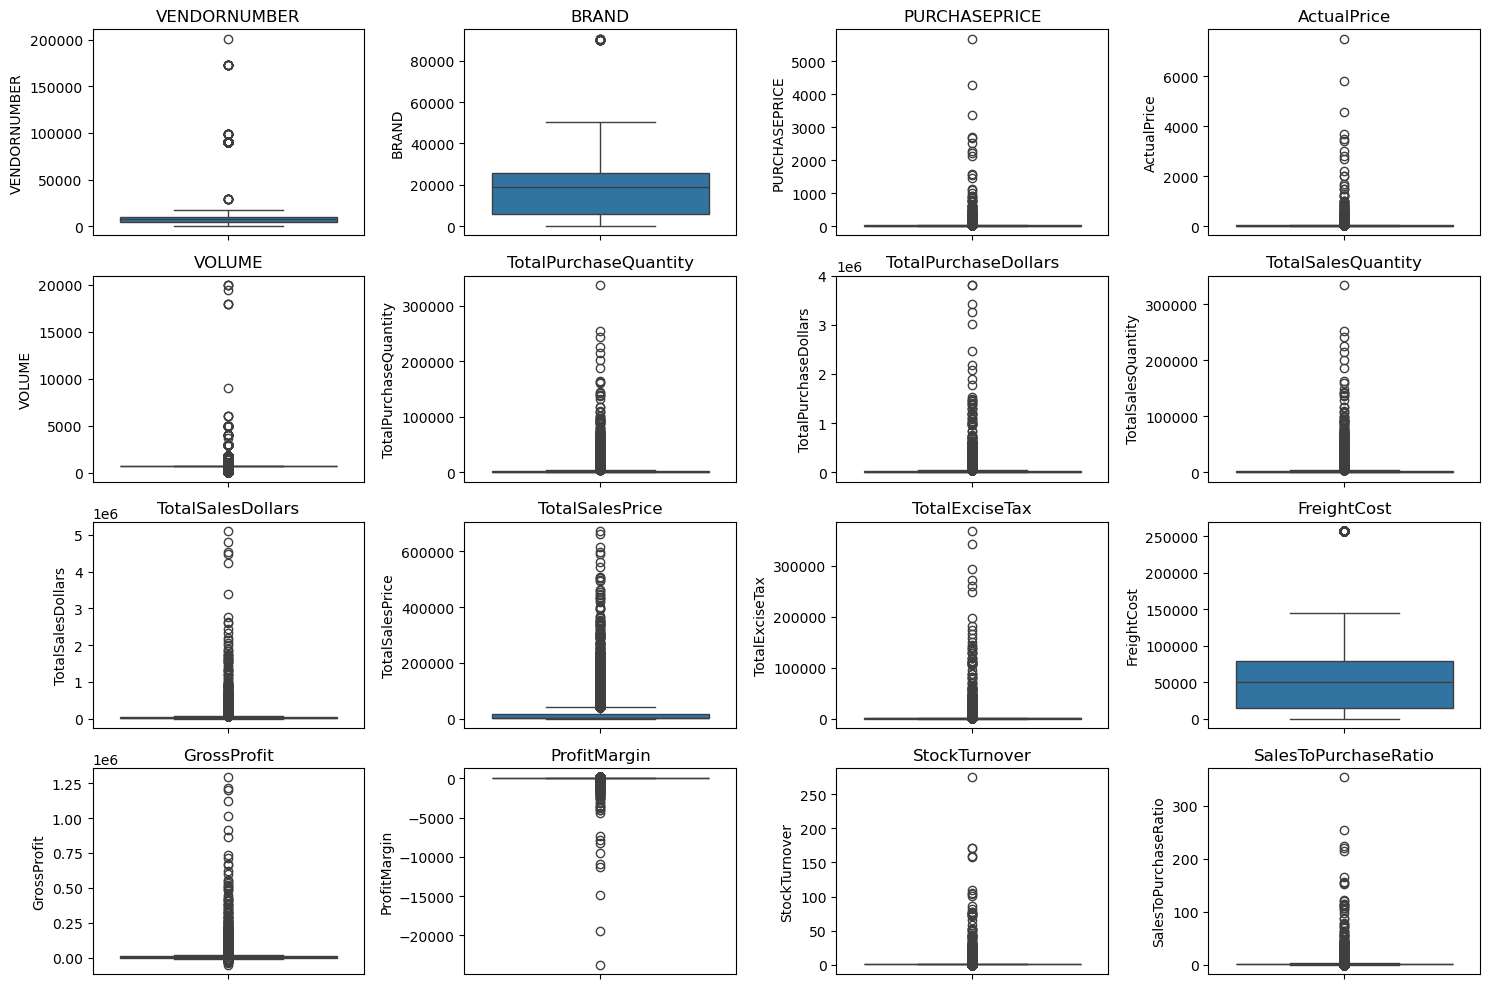

In [5]:
#Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) 
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout() 
plt.show()

# Summary Statistics insights:

 Negative & Zero Values:
  - Gross Profit:Minimum value is -52,002.78, including losses.Some products or transactions may be selling at a loss to high costs or selling at discounts lower than the purchase price..
  - Profit Margin:Has a minimum of -infinity,which cases where revenue is zero or even lower than costs.
  - Total Sales quantity and sales dollars:Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

# Outliers indicated by high standard deviations:
- Purchase and Actual Prices: The max values(5,681.81 & 7,499.99) are significantely higher than the mean(24.39 & 35.64),indicating potential premimum
products.
- Freight cost: Huge variation, from 0.09 to 257,032.07, suggest logistics inefficiencies or bulk shipements.
- Stock Turnover: Range from 0 to 274.5, implying some products sell extremly fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that products is high than purchased qunatity due to sales are being fulfilled from older stock.



In [6]:
#removing inconsistencies data by filter

df=pd.read_sql_query('''SELECT *
FROM vendor_sales_summary
WHERE GrossProfit>0 AND
ProfitMargin >0 AND
TotalSalesQuantity>0''',conn)

In [7]:
df

,VENDORNUMBER,VENDORNAME,BRAND,DESCRIPTION,PURCHASEPRICE,ActualPrice,VOLUME,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


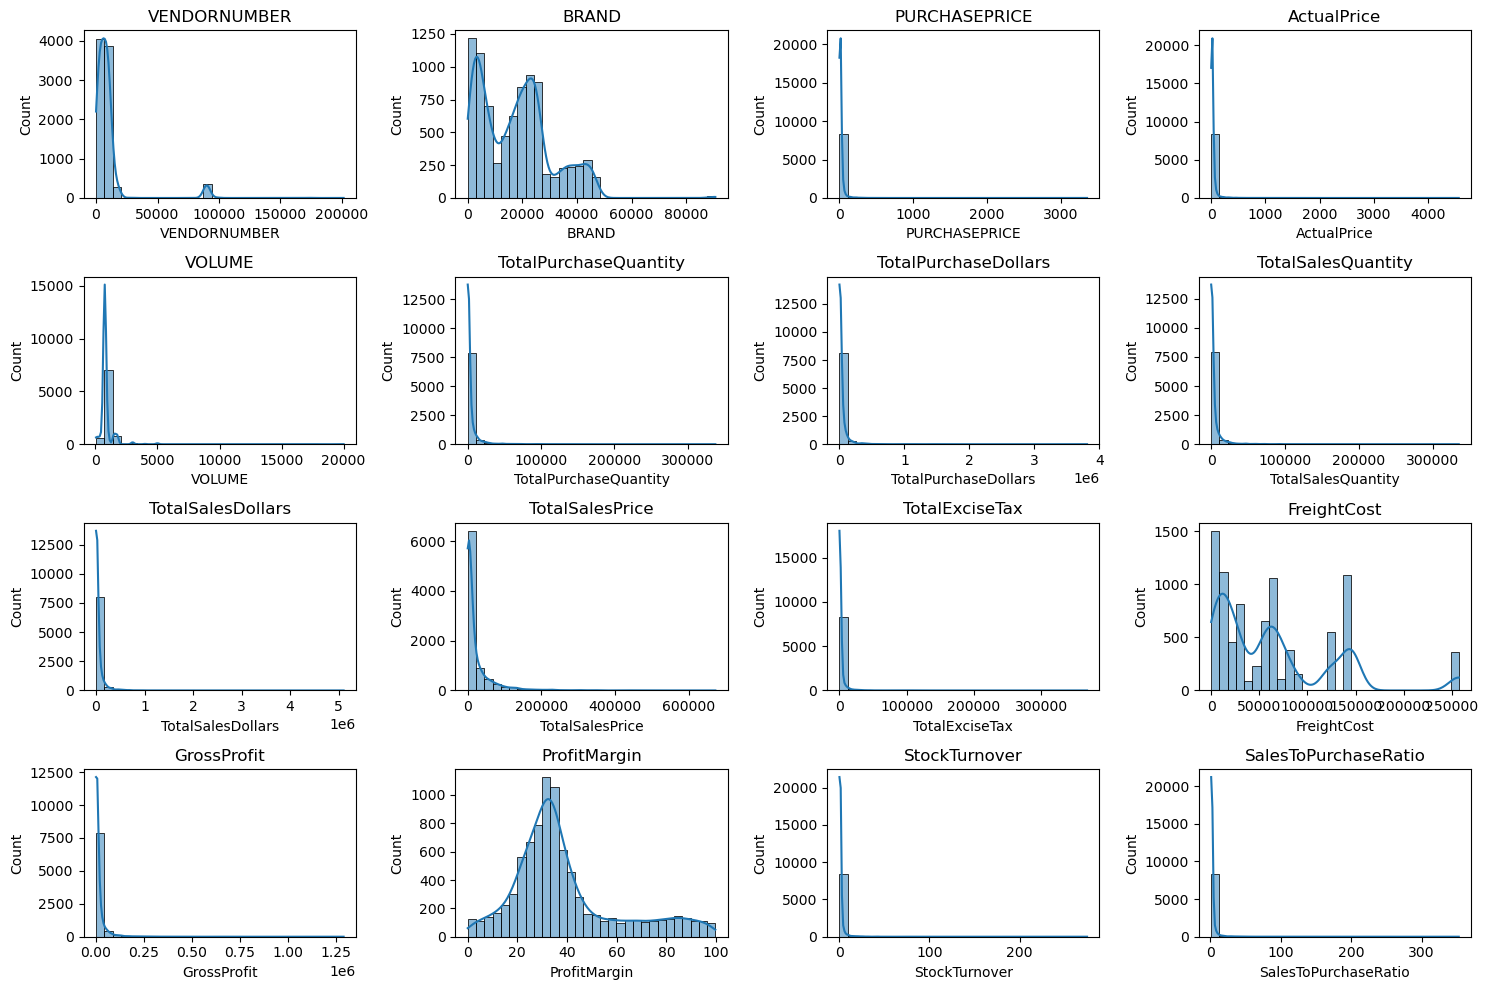

In [8]:
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #adjust the grid layout as needed
    sns.histplot(df[col],kde=True, bins=30)
    plt.title(col)
plt.tight_layout() 
plt.show()

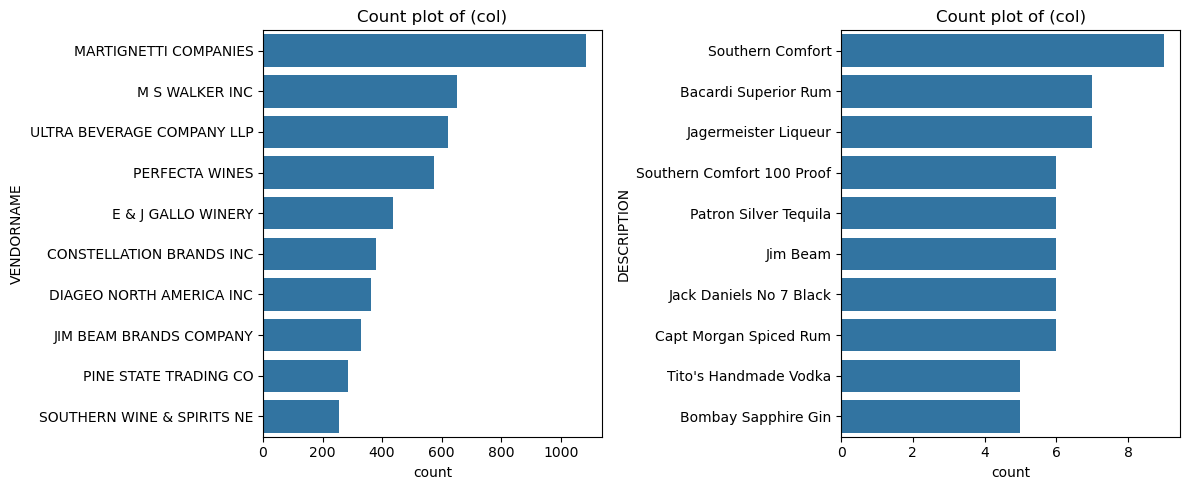

In [9]:
#count plots for categorical cols

categorical_cols=['VENDORNAME','DESCRIPTION']

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2, i+1) 
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) # top 10 categories
    plt.title(f'Count plot of (col)')
plt.tight_layout() 
plt.show()

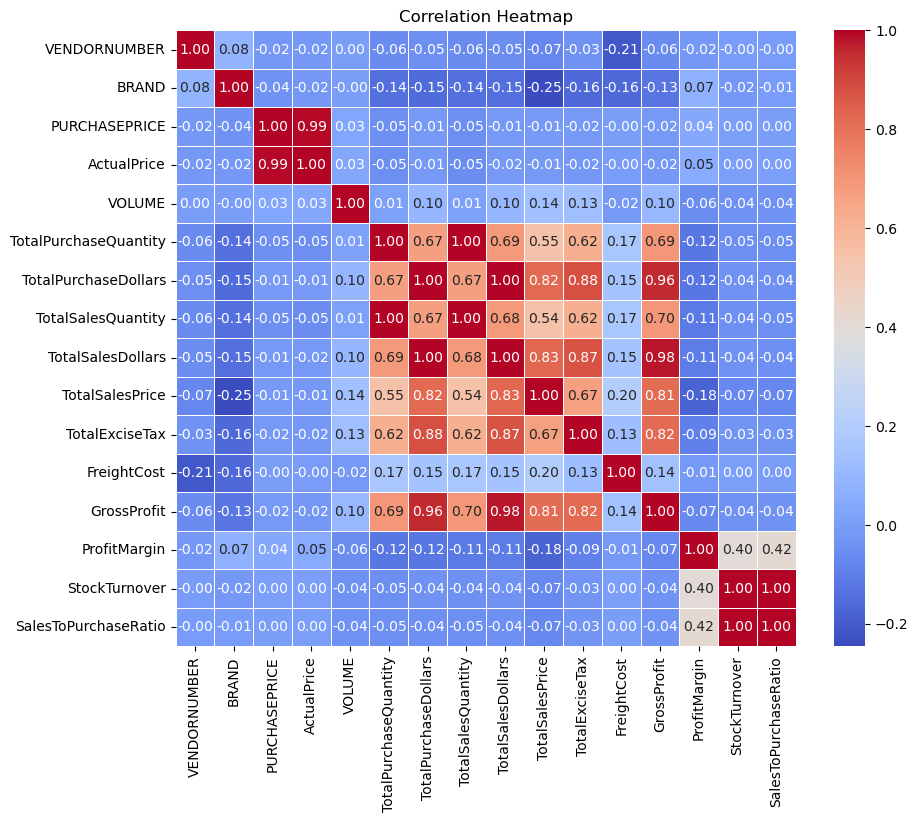

In [10]:
#correlation heatmap

plt.figure(figsize=(10,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Correlation Insights
- PurchasePrice has work correlation with Totalsalesdollars(-0.012) and Grossprofit(-0.016), suggesting that price variation do not significantely impact sales revenue profit.
- Strong correlation between total purchase quantity (0.999), confiriming efficient inventory turnover.
- Nehative correlation between profit margin and total sales price(-0.179) suggests that as sales price increases, margin decreases, possibly die to competitive pricing pressures.
- StockTurnover has weak negative correlations with both Grossprofit(-0.038) and Profitmargin(-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis
- Identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.
  

In [11]:
 brand_performance=df.groupby('DESCRIPTION').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [12]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)


In [13]:
low_sales_threshold

np.float64(560.299)

In [14]:
high_margin_threshold

np.float64(64.97017552750113)

In [15]:
#filter brands with low sales but high profit margin

target_brands=brand_performance[
    (brand_performance['TotalSalesDollars']<=low_sales_threshold) &
    (brand_performance['ProfitMargin']>=high_margin_threshold)
]
print('Brands withlow sales but high profit margin:')
display(target_brands.sort_values('TotalSalesDollars'))

Brands withlow sales but high profit margin:


,DESCRIPTION,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [16]:
brand_performance.to_csv('brand_performance.csv', index=False)

In [17]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000] #for better visualization

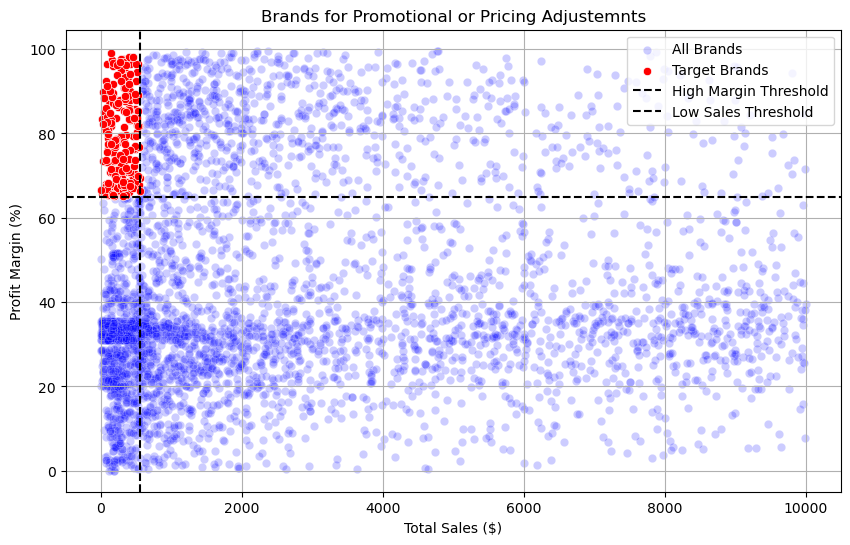

In [18]:
#scatter plot 

plt.figure(figsize=(10,6)) 
sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='ProfitMargin',color='blue',label='All Brands',alpha=0.2) 
sns.scatterplot(data=target_brands,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target Brands') 

plt.axhline(high_margin_threshold,linestyle='--',color='black',label='High Margin Threshold') 
plt.axvline(low_sales_threshold,linestyle='--',color='black',label='Low Sales Threshold') 

plt.xlabel('Total Sales ($)') 
plt.ylabel('Profit Margin (%)') 
plt.title('Brands for Promotional or Pricing Adjustemnts') 
plt.legend() 
plt.grid(True) 
plt.show()



# which vendors and brands demonstrate the highest sales performance?

In [19]:
def format_dollars(value):
    if value>=1_000_000:
        return f'{value/1_000_000:.2f}M'
    elif value>=1_000:
        return f'{value/1_000:.2f}K'
    else:
        return str(value)
           

 

In [20]:
#top vendors and brands by sales performance

top_vendors=df.groupby('VENDORNAME')['TotalSalesDollars'].sum().nlargest(10)
top_brands=df.groupby('DESCRIPTION')['TotalSalesDollars'].sum().nlargest(10)



In [21]:
top_vendors

VENDORNAME
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [22]:
top_brands

DESCRIPTION
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [23]:
top_brands.apply(lambda x: format_dollars(x))


DESCRIPTION
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

# Barplot

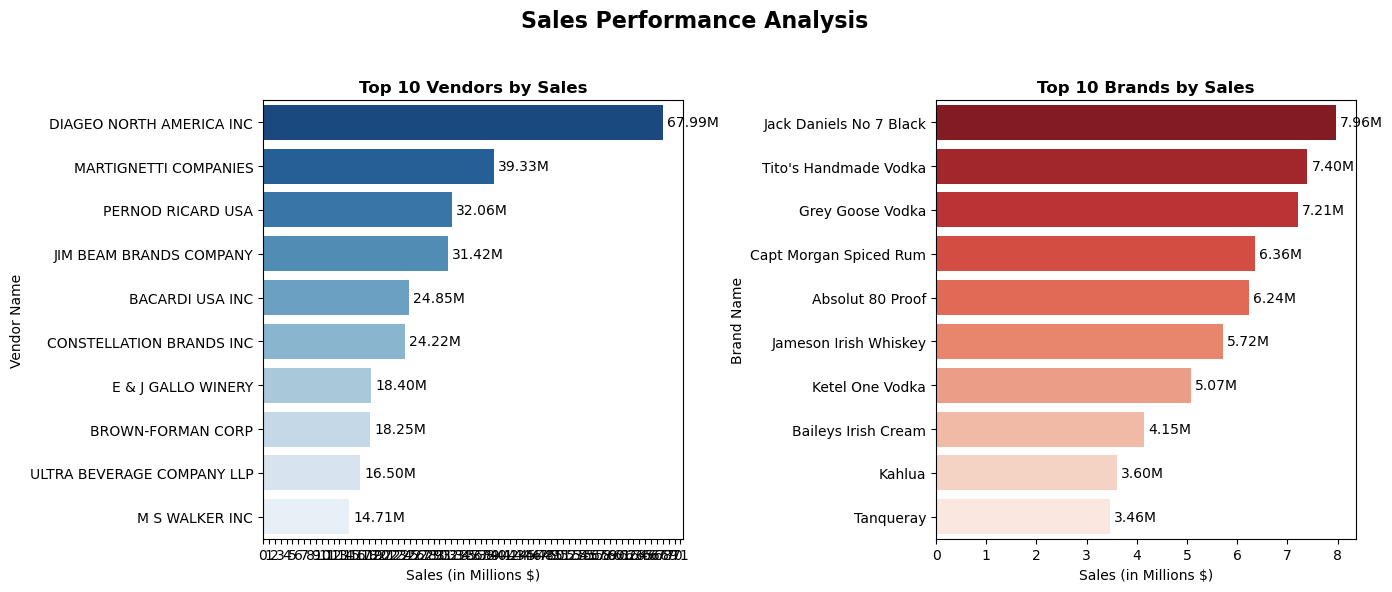

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(14,6))

# ===================== Top Vendors =====================
plt.subplot(1,2,1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette='Blues_r'
)

plt.title('Top 10 Vendors by Sales', fontsize=12, fontweight='bold')
plt.xlabel('Sales (in Millions $)')
plt.ylabel('Vendor Name')


ax1.xaxis.set_major_locator(ticker.MultipleLocator(1e6))
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}'))

# Value labels
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (max(top_vendors.values) * 0.01),
        bar.get_y() + bar.get_height()/2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# ===================== Top Brands =====================
plt.subplot(1,2,2)
ax2 = sns.barplot(
    y=top_brands.index,
    x=top_brands.values,
    palette='Reds_r'
)

plt.title('Top 10 Brands by Sales', fontsize=12, fontweight='bold')
plt.xlabel('Sales (in Millions $)')
plt.ylabel('Brand Name')


ax2.xaxis.set_major_locator(ticker.MultipleLocator(1e6))
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}'))

# Value labels
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (max(top_brands.values) * 0.01),
        bar.get_y() + bar.get_height()/2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Overall title
plt.suptitle('Sales Performance Analysis', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

 - Which vendors contribute the most tp total purchase dollars?

In [25]:
vendor_performance=df.groupby('VENDORNAME').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [26]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [27]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [28]:
#diplay to 10 vendors

top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VENDORNAME,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


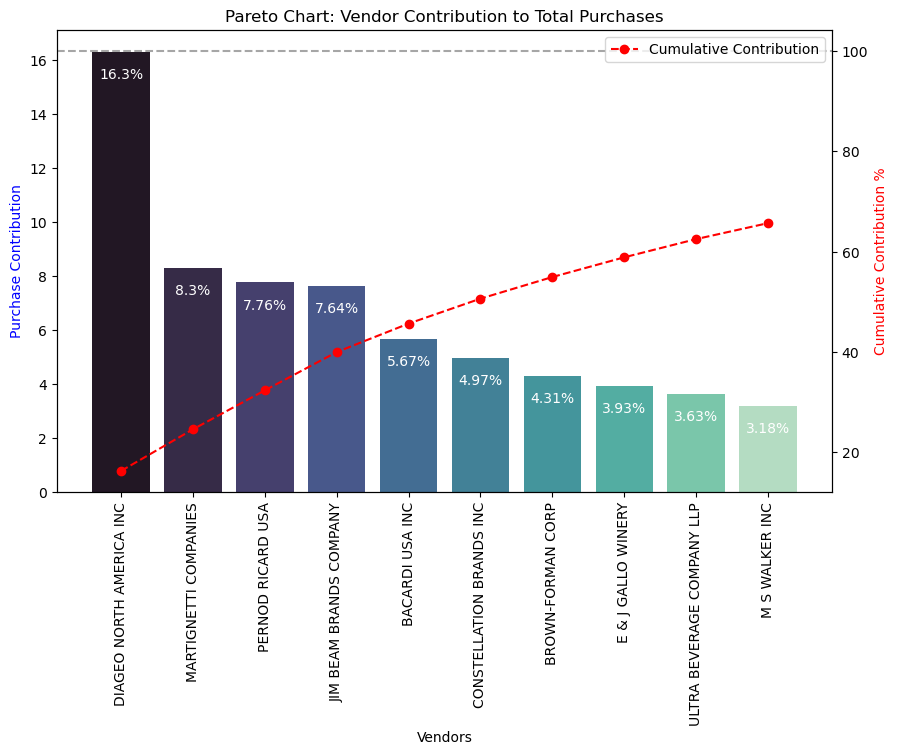

In [29]:
top_vendors['Cumulative_Contribution']=top_vendors['PurchaseContribution%'].cumsum()

# Pareto Chart 
fig, ax1=plt.subplots(figsize=(10,6)) 

# bar plot for purchase contribution 
sns.barplot(x=top_vendors['VENDORNAME'], y=top_vendors['PurchaseContribution%'], palette='mako',ax=ax1) 
for i,value in enumerate(top_vendors['PurchaseContribution%']): 
    ax1.text(i,value-1,str(value)+'%',ha='center',fontsize=10,color='white') 
    
#line plot for cumulative contribution%  
ax2=ax1.twinx() 
ax2.plot(top_vendors['VENDORNAME'], top_vendors['Cumulative_Contribution'],color='red',marker='o',linestyle='dashed',label='Cumulative Contribution') 

ax1.set_xticklabels(top_vendors['VENDORNAME'], rotation=90) 
ax1.set_ylabel('Purchase Contribution',color='blue') 
ax2.set_ylabel('Cumulative Contribution %',color='red') 
ax1.set_xlabel('Vendors') 
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases') 

ax2.axhline(y=100,color='grey',linestyle='dashed',alpha=0.7) 
ax2.legend(loc='upper right') 

plt.show()

#### How much of total procurement is dependent on the top vendors?

In [30]:
print(f'Total Purchase ontribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%')

Total Purchase ontribution of top 10 vendors is 65.69%


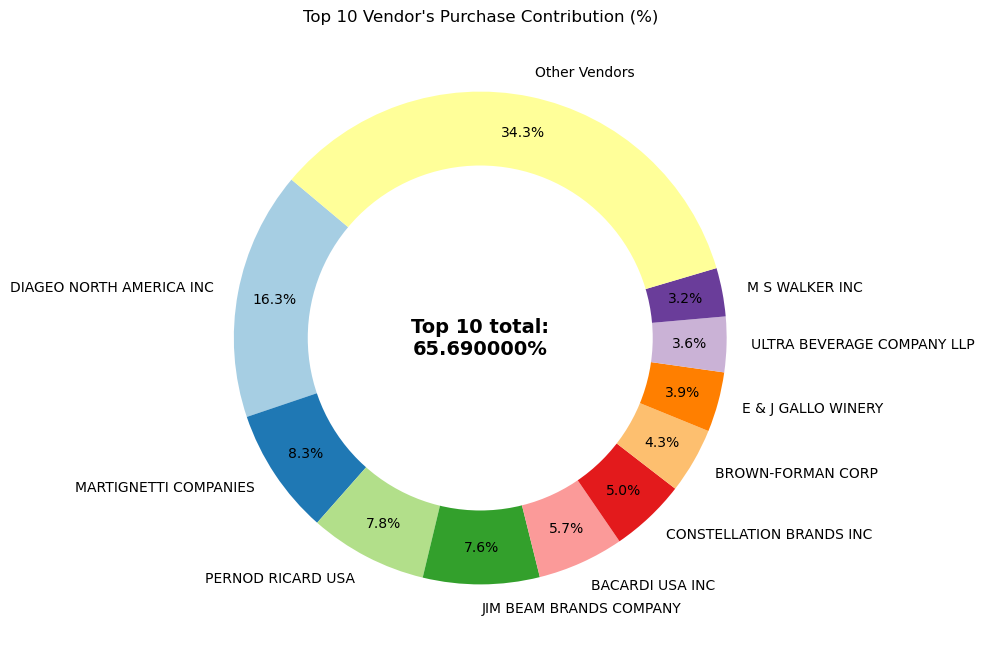

In [31]:
vendors=list(top_vendors['VENDORNAME'].values)
purchase_contribution=list(top_vendors['PurchaseContribution%'].values)
total_contribution=sum(purchase_contribution)
remaining_comntibution=100-total_contribution

# Append 'other vendors' category
vendors.append('Other Vendors')
purchase_contribution.append(remaining_comntibution)

# donut chart
fig, ax=plt.subplots(figsize=(8,8))
wedges,texts,autotexts=ax.pie(purchase_contribution, labels=vendors,autopct='%1.1f%%',
                              startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)

#draw a white circle in the centre to create a 'dount' effect
centre_circle=plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# add total cantribution annotation in the centre
plt.text(0,0, f'Top 10 total:\n{total_contribution:2f}%',fontsize=14,fontweight='bold',ha='center',va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


          


#### Does purchasing in bulk reduce the unity price,and what is the optimal purchase volume for cost saving?

In [32]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [33]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [34]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


In [35]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


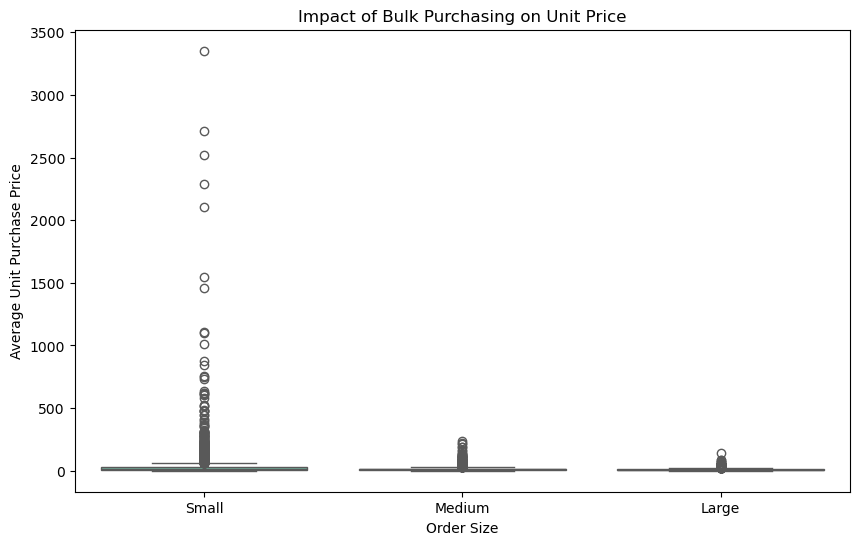

In [36]:
# boxplot

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title('Impact of Bulk Purchasing on Unit Price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

- Vendors buying in bulk(large Order(size) get the lowest unit price($10.78 per unit),meaning higher margins if they can manage inventory efficient.
- The price difference between small and large orders is substantial(-72% reducation in unit cost)
- This suggest that bulk pricing strategies successfully encourage vendores to purchase in large vols,leading to higher overall sales despite lower per-unit revenue.

#### Which vendors have low inventory turnover,indicating excess stock and slow-moving products?


In [37]:
df[df['StockTurnover']<1].groupby('VENDORNAME')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VENDORNAME,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [38]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PURCHASEPRICE'] 
print('Total Unsold Capital:',format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: 2.71M


In [39]:
# Aggregate capital locked per vendor
inventory_value_per_vendor=df.groupby('VENDORNAME')['UnsoldInventoryValue'].sum().reset_index()

# Sort vendors with the highest locked capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by='UnsoldInventoryValue',ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VENDORNAME,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


#### What is the 95% confidence intervals for profit margin of top-performing and low-performing vendors.

In [40]:
top_thershold=df['TotalSalesDollars'].quantile(0.75)
low_thershold=df['TotalSalesDollars'].quantile(0.25)


In [41]:
top_vendors=df[df['TotalSalesDollars']>=top_thershold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_thershold]['ProfitMargin'].dropna()

In [42]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [43]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [44]:
def confidence_interval(data,confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data)) # Standard error
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_val,mean_val-margin_of_error,mean_val+margin_of_error

Top Vendors 95% CI: (30.74,31.61),Mean:31.18
Low Vendors 95% CI: (40.50,42.64),Mean:41.57


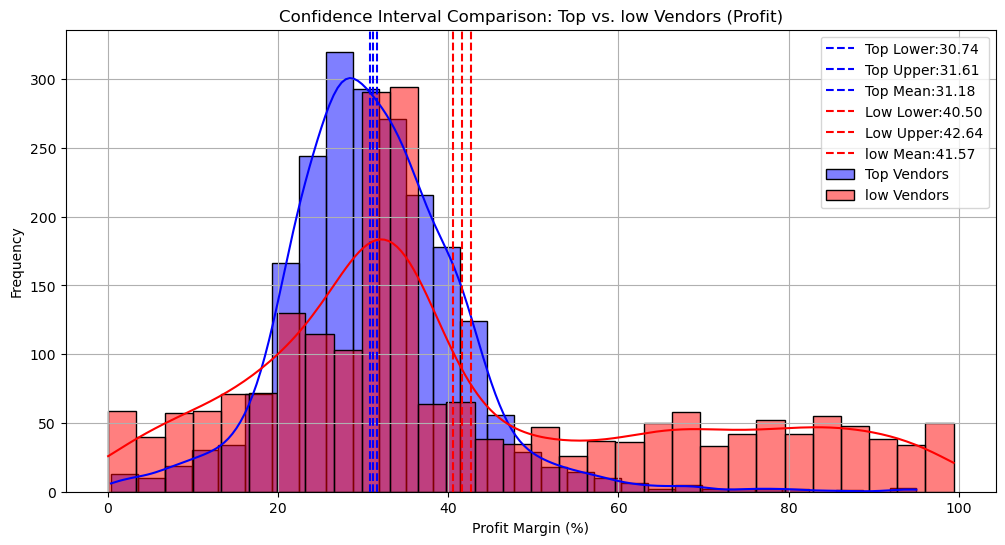

In [45]:
top_mean,top_lower,top_upper=confidence_interval(top_vendors)
low_mean,low_lower,low_upper=confidence_interval(low_vendors)

print(f'Top Vendors 95% CI: ({top_lower:.2f},{top_upper:.2f}),Mean:{top_mean:.2f}')
print(f'Low Vendors 95% CI: ({low_lower:.2f},{low_upper:.2f}),Mean:{low_mean:.2f}')

plt.figure(figsize=(12,6))

#top vendors plot
sns.histplot(top_vendors,kde=True,color='blue',bins=30,alpha=0.5,label='Top Vendors')
plt.axvline(top_lower,color='blue',linestyle='--',label=f'Top Lower:{top_lower:.2f}')
plt.axvline(top_upper,color='blue',linestyle='--',label=f'Top Upper:{top_upper:.2f}')
plt.axvline(top_mean,color='blue',linestyle='--',label=f'Top Mean:{top_mean:.2f}')

#low vendors plot
sns.histplot(low_vendors,kde=True,color='red',bins=30,alpha=0.5,label='low Vendors')
plt.axvline(low_lower,color='red',linestyle='--',label=f'Low Lower:{low_lower:.2f}')
plt.axvline(low_upper,color='red',linestyle='--',label=f'Low Upper:{low_upper:.2f}')
plt.axvline(low_mean,color='red',linestyle='--',label=f'low Mean:{low_mean:.2f}')

#finalize plot
plt.title('Confidence Interval Comparison: Top vs. low Vendors (Profit)')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()



- The confidence interval for low-performing vendors(40.48% to 42.62%) is significantly higher than that of top-performing vendors(30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher margins, pottentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustements, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.


#### Is there a significant difference in profit margin between top-performing vendors?

- Hypothesis:
- H0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vednors.
- H1 (Alternative Hyothesis): Then mean profit margin of top_performing and low_perorming vendors are siginificantely difference.
  
  

In [46]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

top_vendors=df[df['TotalSalesDollars']>=top_thershold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_thershold]['ProfitMargin'].dropna()

# Perform Two-Sample T-Test
t_stat,p_value=ttest_ind(top_vendors,low_vendors,equal_var=False)

#Print results
print(f'T-Statistic: {t_stat:.4f},P-value:{p_value:.4f}')
if p_value<0.05:
    print('Reject H0:There is a significant difference in profit margins top and low-performing vendors.')
else:
    print('Fail to Reject H0: No significant difference in profit margins.')
    
    
    

T-Statistic: -17.6695,P-value:0.0000
Reject H0:There is a significant difference in profit margins top and low-performing vendors.
